---
title: "The rotation zoo, and why rotation matters"
short_title: "00 · Rotation zoo"
subtitle: "PCA / ICA / random / Picard orthogonal mixers, and the demo that shows why a marginal pass needs one"
description: >
  Part 1 Gaussianized one coordinate at a time. That alone gets stuck: it can
  make every marginal standard-normal while the joint stays strongly dependent.
  The fix is an orthogonal rotation between marginal passes — the "between-
  coordinate" half of Gaussianization. This notebook tours the rotation zoo
  (PCA / ICA / random / Picard in rbig), shows that a pure rotation is free
  (log-det 0), and demonstrates the central fact: rotating between marginal
  passes drives total correlation to zero where marginal-only cannot.
---

(sec-nb-rot-00)=
# 00 — The rotation zoo, and why rotation matters

[Part 1](../01_marginal_transforms/00_ecdf_histograms.ipynb) built the atomic
operation of Gaussianization: turn **one** coordinate into a standard normal via
$z_i = \Phi^{-1}(F_i(x_i))$. But a stack of independent 1D maps can only ever fix
the **marginals**. It cannot touch the *dependence between* coordinates — a
product of per-axis maps is, by construction, separable. So if the data is
correlated, marginal Gaussianization makes each axis look $\mathcal{N}(0,1)$ and
then **stalls**, with the joint still far from $\mathcal{N}(0,I)$.

The cure is the other half of Gaussianization: an **orthogonal rotation**
between marginal passes, which mixes information *across* coordinates so the next
marginal pass has something to do. Iterating (marginal → rotate → marginal →
rotate …) is exactly RBIG {cite}`laparra2011rbig`. This notebook is the
conceptual anchor for Part 2.

**What you will see**

- The **rotation zoo** in `rbig` — PCA, ICA, random, Picard — and how they
  differ as orthogonal maps.
- Why a **pure rotation is free**: $\log|\det Q| = 0$ (the Part 0
  [composition](../00_foundations/01_composition_logdet.ipynb) thread), while a
  *whitening* rotation pays a scaling log-det.
- The headline demo: marginal-only Gaussianization **stalls** at high total
  correlation; inserting a rotation drives it to **zero**.
- Rotation *choice* sets the **convergence speed** — PCA in one step, a random
  rotation in a few (previewing Part 3's rotation studies).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import matplotlib.pyplot as plt
import numpy as np

import rbig
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)

## 1. The rotation zoo

A rotation here is an **orthogonal** linear map $z = Q x$ with $Q^\top Q = I$.
Orthogonality buys two things at once: it is exactly invertible
($x = Q^\top z$), and — because $|\det Q| = 1$ — it is **volume-preserving**, so
it contributes **nothing** to the change-of-variables log-determinant. `rbig`
ships a whole zoo, differing only in *how* they pick $Q$:

| rotation | how $Q$ is chosen | when it shines |
|---|---|---|
| **PCA** | eigenvectors of $\mathrm{Cov}(X)$ | scales differ across axes; decorrelates in one shot |
| **ICA** {cite}`hyvarinen2000ica` | maximise non-Gaussianity of the axes | heavy-tailed / non-Gaussian structure |
| **random** | Haar-uniform $Q\sim O(d)$ via QR of a Gaussian | no fitting cost; the RBIG default guarantee |
| **Picard** {cite}`ablin2018faster` | quasi-Newton ICA on the orthogonal manifold | fast, robust ICA |

Let's fit each on a correlated, slightly non-Gaussian 2D cloud and look at the
axes they choose.

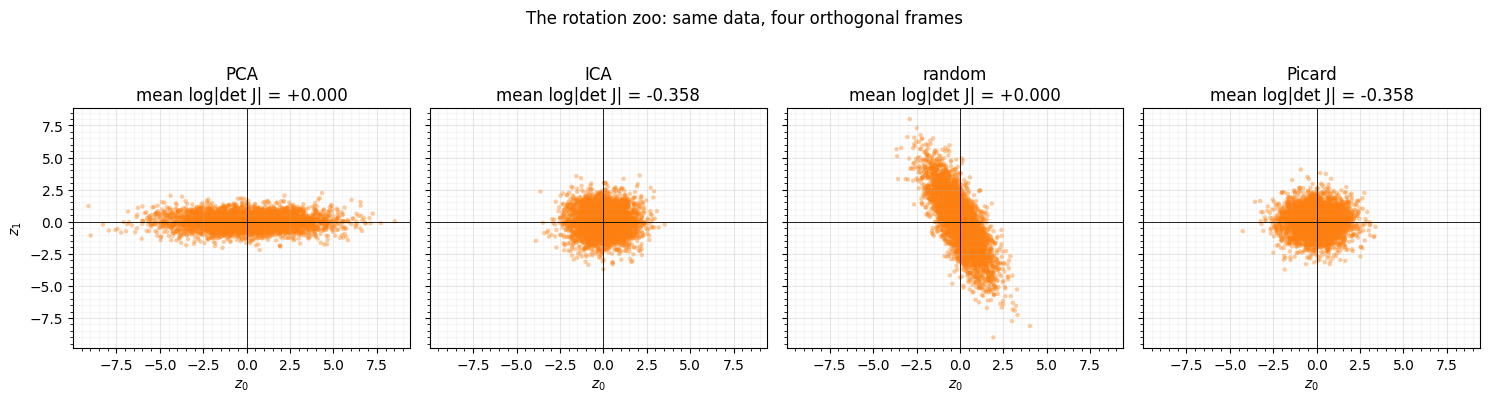

In [2]:
# Correlated, mildly heavy-tailed 2D data: a shared latent + per-axis noise,
# stretched along a diagonal.
n = 4000
s = rng.standard_normal(n)
X = np.stack([2.0 * s + 0.6 * rng.standard_normal(n),
              1.2 * s + 0.6 * rng.standard_normal(n)], axis=1)

rotations = {
    "PCA": rbig.PCARotation(whiten=False),
    "ICA": rbig.ICARotation(random_state=0),
    "random": rbig.RandomRotation(random_state=0),
    "Picard": rbig.PicardRotation(random_state=0),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.9), sharex=True, sharey=True)
for ax, (name, rot) in zip(axes, rotations.items()):
    rot.fit(X)
    Z = rot.transform(X)
    ax.scatter(Z[:, 0], Z[:, 1], color="tab:orange", **SCATTER_KW)
    ld = float(np.mean(rot.log_det_jacobian(X)))
    ax.set(title=f"{name}\nmean log|det J| = {ld:+.3f}", xlabel="$z_0$")
    ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
    style_ax(ax)
axes[0].set_ylabel("$z_1$")
fig.suptitle("The rotation zoo: same data, four orthogonal frames", y=1.02)
fig.tight_layout()

Each rotation re-expresses the *same* cloud in a different orthogonal frame.
**PCA** aligns the axes with the directions of maximum variance (here the
diagonal), so the cloud comes out axis-aligned. **ICA** and **Picard** instead
hunt for the most *non-Gaussian* projections. **Random** just picks some Haar
frame — no fitting at all. Crucially, all four are *pure* rotations: their
mean log-determinant is $0$.

## 2. A pure rotation is free; whitening is not

The log-det printed above was $0$ because $|\det Q| = 1$ for an orthogonal $Q$.
That is the same fact Part 0 used to call rotations "free" inside a composed
flow ([composition log-det](../00_foundations/01_composition_logdet.ipynb)): a
rotation re-frames the data without stretching volume, so it adds nothing to
$\sum_k \log|\det J_k|$. But beware — **PCA-whitening** is a rotation *and* a
per-axis rescale ($z = \Lambda^{-1/2} Q^\top x$), and that scaling is **not**
free:

In [3]:
rot_only = rbig.PCARotation(whiten=False).fit(X)
whiten = rbig.PCARotation(whiten=True).fit(X)
print(f"PCA rotation only (whiten=False): mean log|det J| = "
      f"{np.mean(rot_only.log_det_jacobian(X)):+.4f}   <- free")
print(f"PCA whitening   (whiten=True):    mean log|det J| = "
      f"{np.mean(whiten.log_det_jacobian(X)):+.4f}   <- pays for the rescale")
print(f"  (the rescale contributes -sum(0.5*log(eigvals)) of Cov(X))")

PCA rotation only (whiten=False): mean log|det J| = +0.0000   <- free
PCA whitening   (whiten=True):    mean log|det J| = -0.3585   <- pays for the rescale
  (the rescale contributes -sum(0.5*log(eigvals)) of Cov(X))


So when Part 2 talks about "rotations are free", it means the *orthogonal* part.
A whitening step folds in a diagonal scaling whose log-det is
$-\tfrac12\sum_i\log\lambda_i$ — cheap to compute, but not zero. Most RBIG
variants keep the rotation pure and let the **marginal** step do the rescaling,
which keeps the bookkeeping clean.

## 3. Why rotation matters: the stuck-vs-unstuck demo

Here is the whole reason Part 2 exists. Take strongly correlated data and run
the marginal-Gaussianization step **on its own**, repeatedly. Then run it again
with a rotation inserted between passes. We measure progress with the **total
correlation** {cite}`watanabe1960tc` $\mathrm{TC}(X) = \sum_i H(X_i) - H(X)$ —
the multi-information that is $0$ **iff** the coordinates are independent, and
which `rbig.total_correlation` estimates directly.

In [4]:
def marginal_gaussianize(A):
    """One per-coordinate Gaussianization pass (the Part 1 atom)."""
    return rbig.MarginalGaussianize().fit(A).transform(A)

def total_corr(A):
    return float(rbig.total_correlation(A))

# Highly correlated, near-Gaussian data so that ONLY the dependence is the
# obstacle — marginals are already easy, the joint is not.
s = rng.standard_normal(n)
Xc = np.stack([s + 0.3 * rng.standard_normal(n),
               s + 0.3 * rng.standard_normal(n)], axis=1)

n_iter = 8
schemes = {
    "marginal only": None,
    "marginal + PCA rotation": lambda k: rbig.PCARotation(whiten=False),
    "marginal + random rotation": lambda k: rbig.RandomRotation(random_state=k),
}
histories = {}
for label, make_rot in schemes.items():
    A = Xc.copy()
    tc = [total_corr(A)]
    for k in range(n_iter):
        A = marginal_gaussianize(A)
        if make_rot is not None:
            A = make_rot(k).fit(A).transform(A)
        tc.append(total_corr(A))
    histories[label] = tc
    print(f"{label:28s} TC: " + " ".join(f"{v:5.3f}" for v in tc))

marginal only                TC: 0.922 0.925 0.925 0.925 0.925 0.925 0.925 0.925 0.925


marginal + PCA rotation      TC: 0.922 -0.003 0.000 -0.004 -0.000 0.000 0.000 0.000 0.000


marginal + random rotation   TC: 0.922 0.859 0.002 -0.002 0.001 -0.001 -0.000 -0.001 0.001


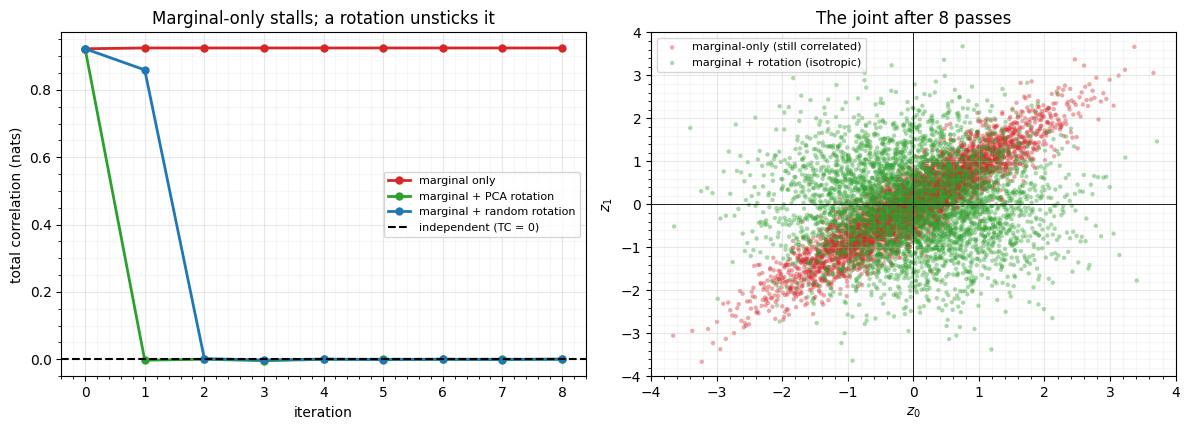

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))

colors = {"marginal only": "tab:red",
          "marginal + PCA rotation": "tab:green",
          "marginal + random rotation": "tab:blue"}
for label, tc in histories.items():
    axL.plot(range(len(tc)), tc, "o-", color=colors[label], lw=2, ms=5, label=label)
axL.axhline(0, **{"color": "k", "lw": 1.5, "ls": "--"}, label="independent (TC = 0)")
axL.set(title="Marginal-only stalls; a rotation unsticks it",
        xlabel="iteration", ylabel="total correlation (nats)")
axL.legend(fontsize=8); style_ax(axL)

# Right: the geometry — marginal-only leaves a tilted Gaussian-on-the-diagonal.
A_marg = Xc.copy()
for _ in range(n_iter):
    A_marg = marginal_gaussianize(A_marg)
axR.scatter(A_marg[:, 0], A_marg[:, 1], color="tab:red", **SCATTER_KW,
            label="marginal-only (still correlated)")
A_rot = Xc.copy()
for k in range(n_iter):
    A_rot = marginal_gaussianize(A_rot)
    A_rot = rbig.PCARotation(whiten=False).fit(A_rot).transform(A_rot)
axR.scatter(A_rot[:, 0], A_rot[:, 1], color="tab:green", **SCATTER_KW,
            label="marginal + rotation (isotropic)")
axR.set(title="The joint after 8 passes", xlabel="$z_0$", ylabel="$z_1$",
        xlim=(-4, 4), ylim=(-4, 4))
axR.axhline(0, color="k", lw=0.6); axR.axvline(0, color="k", lw=0.6)
axR.legend(fontsize=8, loc="upper left"); style_ax(axR)
fig.tight_layout()

**Marginal-only (red) is stuck.** Each pass dutifully makes both axes
$\mathcal{N}(0,1)$, but a separable map can never remove the diagonal
correlation, so the total correlation plateaus around $0.9$ nats forever — the
scatter stays a tilted ellipse pinned to the diagonal. A separable transform has
a separable image; you cannot reach $\mathcal{N}(0,I)$ this way.

**Insert a rotation and the obstacle dissolves.** The rotation mixes the two
coordinates, so the *next* marginal pass sees fresh non-Gaussian structure to
remove. With **PCA** the data is near-Gaussian, so a single decorrelating
rotation collapses TC to $0$ in **one** step. A **random** rotation has no idea
where the correlation lives, so it takes a couple of passes — but it *does*
converge. That robustness is the theoretical heart of RBIG
{cite}`laparra2011rbig`: for near-Gaussian targets *almost any* rotation works,
because each marginal pass can only reduce the total correlation and a generic
rotation keeps exposing reducible structure.

## 4. Rotation choice sets the convergence speed

The demo already hints at it: PCA reached independence in one step, random in
two. That difference — same destination, different *speed* — is what makes
rotation choice a real design knob. We make it explicit by counting passes to
drive TC below a tolerance.

In [6]:
tol = 1e-2
print(f"passes to reach TC < {tol}:")
for label, tc in histories.items():
    if label == "marginal only":
        print(f"  {label:28s} never (plateau at {tc[-1]:.3f})")
        continue
    hit = next((i for i, v in enumerate(tc) if abs(v) < tol), None)
    print(f"  {label:28s} {hit} passes")

passes to reach TC < 0.01:
  marginal only                never (plateau at 0.925)
  marginal + PCA rotation      1 passes
  marginal + random rotation   2 passes


PCA wins here because the data is *Gaussian and correlated* — exactly the case
its eigenvector frame is built for. On heavy-tailed or multimodal data, **ICA**
and **Picard** can win instead by aligning to the non-Gaussian directions, while
**random** is the safe, fit-free default whose only cost is a few extra passes.
Part 3 turns this into a proper [rotation-choice convergence
study](../README.md); here the point is simply that the *between-coordinate*
step is not an afterthought — it is half the algorithm.

## Recap

| idea | takeaway |
|---|---|
| rotation = orthogonal map $z = Qx$ | exactly invertible, **volume-preserving** ($\log|\det Q| = 0$) |
| marginal-only Gaussianization | fixes marginals, **cannot** remove dependence — stalls |
| rotation between passes | mixes coordinates so the next marginal pass progresses → TC $\to 0$ |
| rotation *choice* | sets convergence **speed**: PCA (variance), ICA/Picard (non-Gaussianity), random (free, robust) |
| whitening ≠ pure rotation | the rescale costs a $-\tfrac12\sum\log\lambda_i$ log-det |

**Next up.** A random or PCA rotation is fixed once fit. To *learn* the rotation
end-to-end inside a flow we need an orthogonal matrix that stays orthogonal
under gradient descent. [01 — Householder & trainable orthogonals](01_householder_orthogonal.ipynb)
builds two such parameterisations from scratch — products of Householder
reflections and the Cayley map — both exactly orthogonal, both with log-det $0$.